In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt


In [8]:
indata = pd.read_csv("indata.csv")

In [12]:
indata.head()

,Land,Ride,Wait Time,Local Time,Day of Week,Date,tempmax,tempmin,temp,humidity,...,visibility,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description
0,Pixar Pier,Toy Story Midway Mania!,40.0,2024-09-23 17:30:04,Monday,2024-09-23,78.4,62.4,67.9,80.5,...,5.6,210.0,18.0,8.0,10.0,2024-09-23 06:40:56,2024-09-23 18:46:15,0.69,Partially cloudy,Clearing in the afternoon.
1,Cars Land,Mater's Graveyard JamBOOree,30.0,2024-09-23 17:45:03,Monday,2024-09-23,78.4,62.4,67.9,80.5,...,5.6,210.0,18.0,8.0,10.0,2024-09-23 06:40:56,2024-09-23 18:46:15,0.69,Partially cloudy,Clearing in the afternoon.
2,Hollywood Land,Mickey's PhilharMagic,10.0,2024-09-23 17:45:03,Monday,2024-09-23,78.4,62.4,67.9,80.5,...,5.6,210.0,18.0,8.0,10.0,2024-09-23 06:40:56,2024-09-23 18:46:15,0.69,Partially cloudy,Clearing in the afternoon.
3,Pixar Pier,Jumpin' Jellyfish,20.0,2024-09-23 17:45:03,Monday,2024-09-23,78.4,62.4,67.9,80.5,...,5.6,210.0,18.0,8.0,10.0,2024-09-23 06:40:56,2024-09-23 18:46:15,0.69,Partially cloudy,Clearing in the afternoon.
4,Avengers Campus,WEB SLINGERS: A Spider-Man Adventure,45.0,2024-09-23 18:00:04,Monday,2024-09-23,78.4,62.4,67.9,80.5,...,5.6,210.0,18.0,8.0,10.0,2024-09-23 06:40:56,2024-09-23 18:46:15,0.69,Partially cloudy,Clearing in the afternoon.


In [13]:
indata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339064 entries, 0 to 339063
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Land              339064 non-null  object 
 1   Ride              339064 non-null  object 
 2   Wait Time         339064 non-null  float64
 3   Local Time        339064 non-null  object 
 4   Day of Week       339064 non-null  object 
 5   Date              339064 non-null  object 
 6   tempmax           339064 non-null  float64
 7   tempmin           339064 non-null  float64
 8   temp              339064 non-null  float64
 9   humidity          339064 non-null  float64
 10  precip            339064 non-null  float64
 11  windgust          339064 non-null  float64
 12  windspeed         339064 non-null  float64
 13  winddir           339064 non-null  float64
 14  sealevelpressure  339064 non-null  float64
 15  cloudcover        339064 non-null  float64
 16  visibility        33

In [15]:
target_col = "Wait Time"

# Drop rows with missing target
indata = indata.dropna(subset=[target_col])

# Separate features (X) and target (y)
X = indata.drop(columns=[target_col])
y = indata[target_col]


In [16]:
X_eng = X.copy()

# Convert 'Local Time' to datetime and extract useful components
if "Local Time" in X_eng.columns:
    X_eng["Local Time"] = pd.to_datetime(X_eng["Local Time"], errors="coerce")
    X_eng["hour"] = X_eng["Local Time"].dt.hour
    X_eng["minute"] = X_eng["Local Time"].dt.minute
    X_eng["is_afternoon"] = (X_eng["hour"] >= 12).astype(int)
    # Drop original Local Time
    X_eng = X_eng.drop(columns=["Local Time"])

# Convert 'Date' to datetime and extract components
if "Date" in X_eng.columns:
    X_eng["Date"] = pd.to_datetime(X_eng["Date"], errors="coerce")
    X_eng["dayofweek_num"] = X_eng["Date"].dt.dayofweek  # Monday=0
    X_eng["month"] = X_eng["Date"].dt.month
    X_eng["day"] = X_eng["Date"].dt.day
    X_eng["dayofyear"] = X_eng["Date"].dt.dayofyear
    # Drop original Date (we now have numeric components)
    X_eng = X_eng.drop(columns=["Date"])

X_eng.head()


,Land,Ride,Day of Week,tempmax,tempmin,temp,humidity,precip,windgust,windspeed,...,moonphase,conditions,description,hour,minute,is_afternoon,dayofweek_num,month,day,dayofyear
0,Pixar Pier,Toy Story Midway Mania!,Monday,78.4,62.4,67.9,80.5,0.0,17.7,7.8,...,0.69,Partially cloudy,Clearing in the afternoon.,17,30,1,0,9,23,267
1,Cars Land,Mater's Graveyard JamBOOree,Monday,78.4,62.4,67.9,80.5,0.0,17.7,7.8,...,0.69,Partially cloudy,Clearing in the afternoon.,17,45,1,0,9,23,267
2,Hollywood Land,Mickey's PhilharMagic,Monday,78.4,62.4,67.9,80.5,0.0,17.7,7.8,...,0.69,Partially cloudy,Clearing in the afternoon.,17,45,1,0,9,23,267
3,Pixar Pier,Jumpin' Jellyfish,Monday,78.4,62.4,67.9,80.5,0.0,17.7,7.8,...,0.69,Partially cloudy,Clearing in the afternoon.,17,45,1,0,9,23,267
4,Avengers Campus,WEB SLINGERS: A Spider-Man Adventure,Monday,78.4,62.4,67.9,80.5,0.0,17.7,7.8,...,0.69,Partially cloudy,Clearing in the afternoon.,18,0,1,0,9,23,267


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_eng, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((271251, 30), (67813, 30))

In [18]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in numeric_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['tempmax', 'tempmin', 'temp', 'humidity', 'precip', 'windgust', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'moonphase', 'hour', 'minute', 'is_afternoon', 'dayofweek_num', 'month', 'day', 'dayofyear']
Categorical features: ['Land', 'Ride', 'Day of Week', 'sunrise', 'sunset', 'conditions', 'description']


In [19]:
# Numeric pipeline: impute missing values with median
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Categorical pipeline: impute missing values and one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine them with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [20]:
gbr_model = GradientBoostingRegressor(
    n_estimators=200,      # number of boosting stages
    learning_rate=0.05,   # shrinkage factor
    max_depth=3,          # depth of individual trees
    random_state=42
)

# Create the full pipeline: preprocessing + model
gbr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", gbr_model)
])

# Train the model
gbr_pipeline.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [22]:
y_train_pred = gbr_pipeline.predict(X_train)
y_test_pred = gbr_pipeline.predict(X_test)

def regression_metrics(y_true, y_pred, label=""):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{label}MAE : {mae:.2f}")
    print(f"{label}RMSE: {rmse:.2f}")
    print(f"{label}R²  : {r2:.3f}")
    print("-" * 30)

print("Train metrics:")
regression_metrics(y_train, y_train_pred, label="Train ")

print("Test metrics:")
regression_metrics(y_test, y_test_pred, label="Test ")

Train metrics:
Train MAE : 9.81
Train RMSE: 190.06
Train R²  : 0.686
------------------------------
Test metrics:
Test MAE : 9.76
Test RMSE: 186.68
Test R²  : 0.688
------------------------------


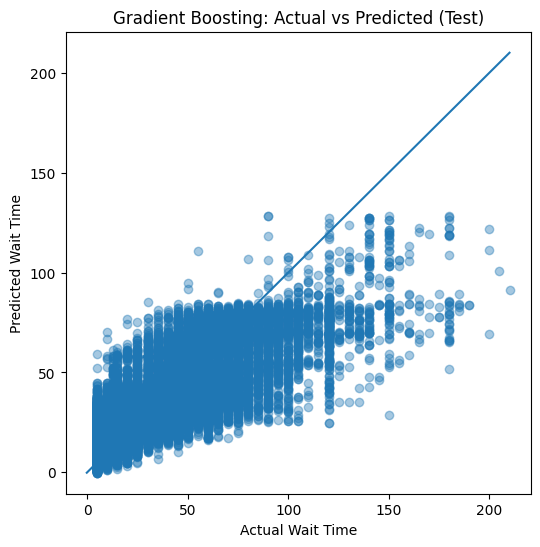

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.4)
plt.xlabel("Actual Wait Time")
plt.ylabel("Predicted Wait Time")
plt.title("Gradient Boosting: Actual vs Predicted (Test)")
# Diagonal reference line
lims = [
    min(y_test.min(), y_test_pred.min()),
    max(y_test.max(), y_test_pred.max()),
]
plt.plot(lims, lims)
plt.show()